In [ ]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset 
import matplotlib.pyplot as plt
import ast

# Loading Data 
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) # Convert string representation of list to actual list

In [ ]:
# Displaying the first 5 rows of the DataFrame with selected columns
df[['job_title_short', 'job_skills']].head(5)

# Exploding the job_skills column to create a new row for each skill
df_exploded =df.explode('job_skills')

In [12]:
# Grouping by job_title_short and job_skills to count the number of occurrences of each skill for each job title
skills_count = df_exploded.groupby(['job_title_short','job_skills']).size()

type(skills_count)

pandas.Series

In [16]:
# Resetting the index of the skills_count Series to convert it into a DataFrame and renaming the count column to 'skills_count'
df_skills_count = skills_count.reset_index(name = 'skills_count')
# Sorting the DataFrame by the 'skills_count' column in descending order to see the most common skills for each job title
df_skills_count = df_skills_count.sort_values(by = 'skills_count', ascending = False)

type(df_skills_count)

pandas.DataFrame

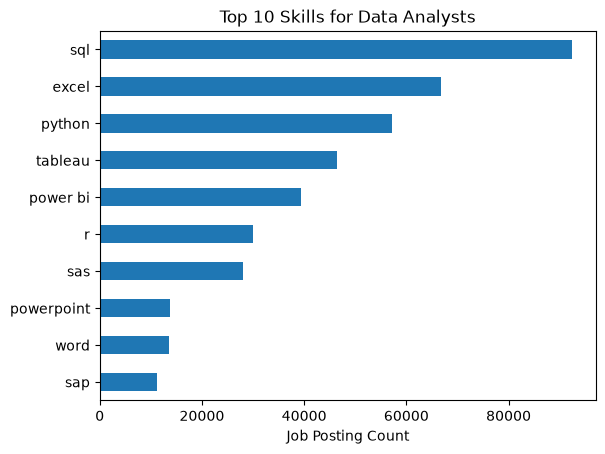

In [28]:
job_title = 'Data Analyst' # Job title to filter the skills for
top_skills = 10 # Number of top skills to display

# Filtering the DataFrame to get the top skills for the specified job title
df_skills_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)

# Plotting the top skills for the specified job title
df_skills_final.plot(kind = 'barh', x='job_skills', y='skills_count')
plt.gca().invert_yaxis() # Invert y-axis to have the highest count at the top 
plt.title(f'Top {top_skills} Skills for {job_title}s') # Title of the plot
plt.xlabel('Job Posting Count') # Label for x-axis
plt.ylabel('') # Label for y-axis
plt.legend().set_visible(False) # Hide legend
plt.show() # Show the plot
